In [2]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [3]:

# Step 2: Load Data
df = pd.read_csv("/content/gold_price_data.csv")   # Replace with your file path
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df


,open,high,low,close,adj_close,volume
date,,,,,,
2004-11-18,44.380001,44.380001,44.490002,44.070000,44.430000,5992000
2004-11-19,44.779999,44.779999,44.919998,44.470001,44.490002,11655300
2004-11-22,44.950001,44.950001,44.970001,44.740002,44.750000,11996000
2004-11-23,44.750000,44.750000,44.919998,44.720001,44.880001,3169200
2004-11-24,45.049999,45.049999,45.049999,44.790001,44.930000,6105100
...,...,...,...,...,...,...
2025-08-06,310.500000,310.500000,311.239990,309.839996,310.320007,7418200
2025-08-07,313.119995,313.119995,313.140015,310.700012,311.720001,10891500
2025-08-08,313.049988,313.049988,313.529999,311.000000,312.350006,19886800


In [5]:

# Use only 'close' price for prediction
data = df[['close']].values

# Step 3: Normalize Data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)
scaled_data


array([[0.01113057],
       [0.01259032],
       [0.01357566],
       ...,
       [0.98525652],
       [0.97295817],
       [0.9696007 ]])

In [6]:

# Step 4: Prepare Training Data
train_size = int(len(scaled_data) * 0.8)  # 80% train, 20% test
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size-60:]   # keep last 60 for sequence

X_train, y_train = [], []
for i in range(60, len(train_data)):   # 60 timesteps
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Step 5: Build LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))   # output layer

model.compile(optimizer='adam', loss='mean_squared_error')

# Step 6: Train Model
history = model.fit(X_train, y_train, batch_size=32, epochs=20)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - loss: 0.0091
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 7.4427e-04
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 4.6597e-04
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 3.8281e-04
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 3.4942e-04
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 2.8291e-04
Epoch 7/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 2.5238e-04
Epoch 8/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 2.4613e-04
Epoch 9/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 2.1853e-04
Epoch 10/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 2.1567e-04
Epoch 11/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 2.2371e-04
Epoch 12/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 2.0768e-04
Epoch 13/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 2.3060e-04
Epoch 14/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 2.0705

In [7]:

# Step 7: Prepare Test Data
X_test, y_test = [], []
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    y_test.append(test_data[i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Step 8: Predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # rescale back


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


/tmp/ipython-input-3395039826.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


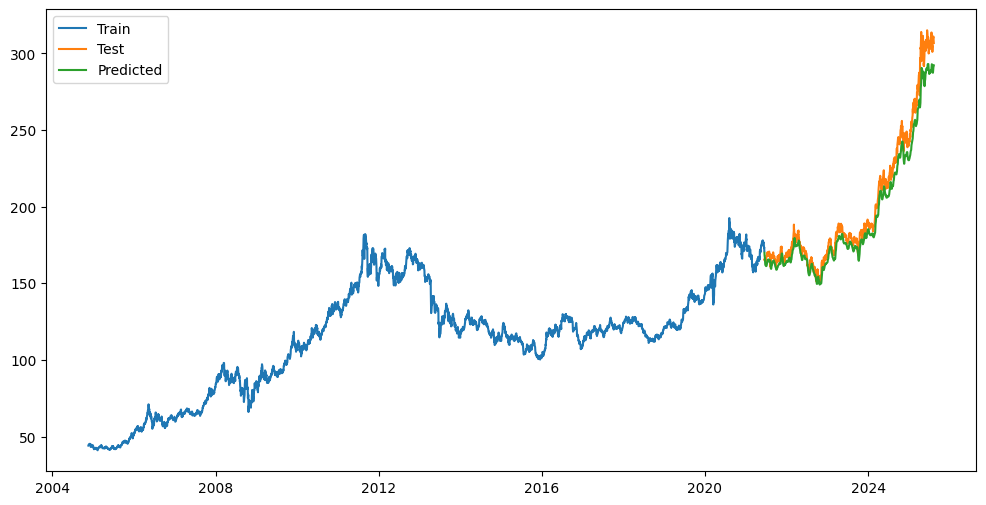

In [8]:

# Step 9: Plot Results
train = df[:train_size]
valid = df[train_size:]
valid['Predictions'] = predictions

plt.figure(figsize=(12,6))
plt.plot(train['close'], label="Train")
plt.plot(valid['close'], label="Test")
plt.plot(valid['Predictions'], label="Predicted")
plt.legend()
plt.show()
